# Scientific computing with Julia
#### Author - Job Feldbrugge

This tutorial serves as a first introduction into scientific computing with Julia. Rather than providing an in depth understanding of the Julia programming language, this workshop is aimed at introducing you to elementary examples of scientific computing to help you get started.

**Parts 5, 6, and 7 will be marked as the first part of Homework 5. They are due on GitHub by 12pm on Friday, 3 April.**

| <p align='left'> Part                | <p align='left'> Marks possible |  <p align='left'> Marks awarded |
| ------------------------------------- | --- | --- |
| <p align='left'> 1. Create a struct  | <p align='left'> -- | -- |
| <p align='left'> 2. Create a function  | <p align='left'> -- | -- |
| <p align='left'> 3. For loops | <p align='left'> -- | -- |
| <p align='left'> 4. Integration | <p align='left'> -- | -- |
| <p align='left'> 5. Parallelization  | <p align='left'> 2 |  |
| <p align='left'> 6. Polynomials  | <p align='left'> 1 |  |
| <p align='left'> 7. Forward differentiation  | <p align='left'> 2 |  |
| <p align='left'> 8. Homotopy continuation  | <p align='left'> -- | -- |
| <p align='left'> **Total** | <p align='left'> max **5** | |

## Part 1: Create a struct 

In [ ]:
pip install julia

In Julia, you commonly use pre-developed data types. A variable can be an integer, a floating point number, a complex number a matrix or an array. In practice, it is very common to build your own composite types, wrapping relevant variables into a `struct` object (a class in Python). Read up on the use of composite types using the documentation https://docs.julialang.org/en/v1/manual/types/#Composite-Types and https://docs.julialang.org/en/v1/manual/types/#Mutable-Composite-Types.

Write a `struct Point` representing a point in the two-dimensional plane $\mathbb{R}^2$. 

In [ ]:
mutable struct Point
    x_coord
    y_coord
end

Initialize an instance of the `struct Point`  at position $(2, 3)$ and read out its attributes.

In [ ]:
point_1= Point(2,3)
println(point_1.x_coord, point_1.y_coord)


23


 Try to change the $x$ component of the point. What goes wrong? Fix this issue. 

In [ ]:
point_1.x_coord =1
println(point_1.x_coord, point_1.y_coord)

13


## Part 2: Create a function

 Write a function that takes two `mutable struct Point` objects and outputs their sum. Evaluate the function on two points.

Note: you may need to restart the kernel to use updated packages.


In [ ]:
function add(a::Point,b::Point)
    return Point(a.x_coord+b.x_coord,a.y_coord+b.y_coord)
end

println("Try addition of 2 points:", add(Point(1,2),Point(2,3)))

Try addition of 2 points:Point(3, 5)


## Part 3: For loops

Read up on how to write a `for` loop in the documentation https://docs.julialang.org/en/v1/manual/control-flow/#man-loops

Julia is a function-oriented language. Place all your calculations in functions to make Julia compile and optimize them for you. Read up on how to define a function in the documentation https://docs.julialang.org/en/v1/manual/functions/

Write a for loop that translates the origin $p = (0,0)$ $5$ times by a unit step in the $y$ direction $\Delta = (0,1)$ with the function developed in question 5.

In [ ]:

function translate()
    p=Point(0,0)
    delta = Point(0,1)
    for i in 1:5
        p = add(p,delta)
    end
    return p
end
println("The translated point is", translate())

The translated point isPoint(0, 5)


## Part 4: Integration

In practice, one often wants to integrate functions. A common method is known as Gaussian Quadrature, where the integral over the domain $[-1,1]$ is approximated by a sum over the function value in a strategically chosen set of points $x_i$ weighted by a set of weights $\omega_i$.

$$\int_{-1}^{1} f(x)\mathrm{d}x \approx \sum_{i=1}^N \omega_i f(x_i)$$

Read up on the documenting of the FastGaussQuadrature.jl library at https://juliaapproximation.github.io/FastGaussQuadrature.jl/stable/

Use FastGaussQuadrature.jl to approximate the integral $\int_{-1}^1 (x^2 - 2 x^4) \mathrm{d}x$ with Gauss-Legendre Quadratures. To what order $N$ do you need to go for an accurate answer?

In [ ]:
import Pkg; Pkg.add("FastGaussQuadrature")
using FastGaussQuadrature, LinearAlgebra

f(x) = x^2 -2*x^4

for N in 1:5
    x,w = gausslegendre(N)
    approx = sum(x .* f.(x))
    println("N= $N, integral  ≈ $approx")
end

    Updating registry at `C:\Users\s1905307\.julia\registries\General.toml`
   Resolving package versions...
   Installed StaticArrays ───── v1.9.18
   Installed SpecialFunctions ─ v2.7.2
    Updating `C:\Users\s1905307\.julia\environments\v1.12\Project.toml`
  [442a2c76] + FastGaussQuadrature v1.1.0
    Updating `C:\Users\s1905307\.julia\environments\v1.12\Manifest.toml`
  [ffbed154] + DocStringExtensions v0.9.5
  [442a2c76] + FastGaussQuadrature v1.1.0
  [92d709cd] + IrrationalConstants v0.2.6
  [692b3bcd] + JLLWrappers v1.7.1
  [2ab3a3ac] + LogExpFunctions v0.3.29
  [aea7be01] + PrecompileTools v1.3.3
  [21216c6a] + Preferences v1.5.2
  [276daf66] + SpecialFunctions v2.7.2
  [90137ffa] + StaticArrays v1.9.18
  [1e83bf80] + StaticArraysCore v1.4.4
  [efe28fd5] + OpenSpecFun_jll v0.5.6+0
  [56f22d72] + Artifacts v1.11.0
  [ade2ca70] + Dates v1.11.0
  [8f399da3] + Libdl v1.11.0
  [37e2e46d] + LinearAlgebra v1.12.0
  [de0858da] + Printf v1.11.0
  [9a3f8284] + Random v1.11.0
  [ea8e919c]

N= 1, integral  ≈ 0.0
N= 2, integral  ≈ 0.0
N= 3, integral  ≈ 0.0
N= 4, integral  ≈ 0.0
N= 5, integral  ≈ 0.0


Bonus question: Why is Gaussian quadratures so efficient? For what kind of functions should it be used? Have a look at https://en.wikipedia.org/wiki/Gaussian_quadrature

## Part 5: Parallelization

When evaluating a function multiple times with different arguments, it is often useful to perform the calculation in parallel. Have a look at the documentation https://docs.julialang.org/en/v1/manual/parallel-computing/ and https://docs.julialang.org/en/v1/manual/multi-threading/#man-multithreading

Implement the integral $I(a) = \int_{-1}^1 \cos (a x) \mathrm{d}x = \frac{2 \sin a}{a}$ in the domain $a\in [-10,10]$ using FastGaussQuadrature.jl in parallel.
Let $a$ vary over the domain in steps of size $0.1$.
Use the ```Threads.@threads``` command, from the library ```Base.Threads```. (You don't need to restart Julia with multiple threads; just implement a "data race").

In [ ]:
using Base.Threads

function integratePar(N)
    x, w = gausslegendre(N)
    avals = -10:0.1:10
    I = Vector{Float64}(undef, length(avals))

    @threads for i in eachindex(avals)
        a = avals[i]
        I[i] = dot(w, cos.(x .* a))
    end

    return I
end

integratePar (generic function with 1 method)

 Plot the result, using the Plots.jl library https://docs.juliaplots.org/stable/
To what order $N$ do we need the Gauss-Legendre Quadrature method for reasonable convergence?

In [ ]:
avals, I = integratePar(50)

for (a, y) in zip(avals, I)
    if abs(a) <= 0.3
        println("a = $a, I = $y")
    end
end

a = -0.10880422217787415, I = -0.09243149369198442


   Resolving package versions...
   Installed Xorg_libpciaccess_jll ─ v0.18.1+0
   Installed Cairo_jll ───────────── v1.18.6+0
   Installed libva_jll ───────────── v2.23.0+0
   Installed libpng_jll ──────────── v1.6.56+0
   Installed FreeType2_jll ───────── v2.14.3+1
   Installed DataStructures ──────── v0.19.4
   Installed JSON ────────────────── v1.5.0
   Installed HTTP ────────────────── v1.11.0
   Installed libdrm_jll ──────────── v2.4.125+1
   Installed FFMPEG_jll ──────────── v8.0.1+1
   Installed StructUtils ─────────── v2.7.1
  Installing 4 artifacts
   Installed artifact FreeType2             1.6 MiB
   Installed artifact libpng                494.9 KiB
   Installed artifact Cairo                 2.9 MiB
   Installed artifact FFMPEG                11.8 MiB
    Updating `C:\Users\s1905307\.julia\environments\v1.12\Project.toml`
  [91a5bcdd] + Plots v1.41.6
    Updating `C:\Users\s1905307\.julia\environments\v1.12\Manifest.toml`
  [66dad0bd] + AliasTables v1.1.3
  [d1d4a3ce] + B

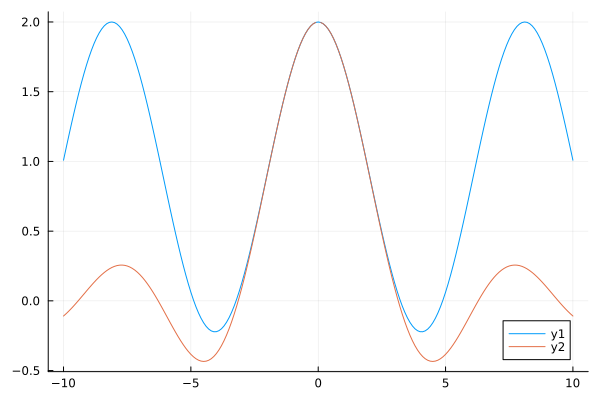

In [ ]:
import Pkg; Pkg.add("Plots")
using Plots
x=range(-10,10,length=201)
res=integratePar(3)
f(b)=2*sin(b)/b
plot(x, [res f.(x)])

## Part 6: Polynomials

When you know what kind of function you are working with, many optimalizations are possible. We here consider the frequently used polynomial functions using Polynomials.jl  https://juliamath.github.io/Polynomials.jl/stable/

Define the function $f(x) = x^2 - 2 x^4$ and evaluate its derivative, antiderivative and roots.

In [ ]:
import Pkg; Pkg.add("Polynomials")
import Pkg; Pkg.add("ForwardDiff")
using Polynomials, ForwardDiff

P_1 = Polynomial([0,0,1,0,-2])

df =derivative(P_1)
println(df)
ad = integrate(P_1)
print(ad)
r = roots(P_1)
println(r)

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\s1905307\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\s1905307\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\s1905307\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\s1905307\.julia\environments\v1.12\Manifest.toml`


2*x - 8*x^3
0.333333*x^3 - 0.4*x^5[-0.7071067811865476, 0.7071067811865475, 0.0, 0.0]


## Part 7: Differentiate a function with forward automatic differentiation

Study the documentation of ForwardDiff.jl on automatic forward differentiation https://juliadiff.org/ForwardDiff.jl/stable/

Use the automatic forward differentiation method from FowardDiff.jl to differentiate $f(x) = \cos x$ in the point $x=\pi/2$. 

In [ ]:
using ForwardDiff
f(x) = cos(x)
df = ForwardDiff.derivative(f,pi/2)
println(df)

-1.0


Compare the result with the first order finite-difference derivative $f'(x) = \frac{f(x+ \delta) - f(x- \delta) }{2 \delta}$ as a function of $\delta$ as we approach the limit $\delta \to 0$. E.g. consider $\delta = 2^{-n}$ for $n=1,2,3,...$.

 For how small a $\delta$ does the finite difference method start to fail?

In [ ]:
using ForwardDiff
f(x) = cos(x)
for n in 1:40
    d = 1/2^n
    fd = (f(pi/2+d)-f(pi/2-d))/(2*d)
    err = abs(fd+1)
    println(rpad(n,4), rpad(d,13), rpad(fd,24),err)
end

1   0.5          -0.958851077208406      0.04114892279159399
2   0.25         -0.9896158370180917     0.010384162981908251
3   0.125        -0.9973978670818215     0.002602132918178457
4   0.0625       -0.9993490854780832     0.00065091452191679
5   0.03125      -0.9998372475304345     0.00016275246956554135
6   0.015625     -0.9999593103925358     4.068960746417272e-5
7   0.0078125    -0.9999898275050023     1.0172494997684467e-5
8   0.00390625   -0.9999974568704298     2.5431295701539014e-6
9   0.001953125  -0.9999993642172437     6.357827563308049e-7
10  0.0009765625 -0.9999998410542882     1.5894571181451767e-7
11  0.00048828125-0.9999999602635705     3.9736429480186075e-8
12  0.000244140625-0.9999999900658926     9.93410742555767e-9
13  0.0001220703125-0.9999999975164732     2.483526828633842e-9
14  6.103515625e-5-0.9999999993791182     6.208817904251873e-10
15  3.0517578125e-5-0.9999999998447795     1.5522050311744806e-10
16  1.52587890625e-5-0.9999999999611948     3.880518129051

## Part 8: Homotopy Continuation

In algebraic geometry we consider the zero set of multivariate polynomials. These zero sets can be numerically evaluated using Homotopy Continuation, where topology meets scientific computing. Read the documentation and go through a couple examples of HomotopyContinuation.jl on the sites https://www.juliahomotopycontinuation.org/ and https://www.juliahomotopycontinuation.org/guides/introduction/

Find the zero set $V(f_1,f_2)$ of the polynomials 

$$ f_1(x,y) = y^2 - x^3 + x$$
$$ f_2(x,y) =  x - y$$

representing the intersection of a line and an elliptic curve.

In [ ]:
import Pkg; Pkg.add("HomotopyContinuation")
using HomotopyContinuation

@var x y
P_1 = y^2 - x^3 +x
P_2 = x -y 
F = System([P_1,P_2])
result = solve(F)

   Resolving package versions...
   Installed StarAlgebras ──────────── v0.3.0
   Installed SemialgebraicSets ─────── v0.3.5
   Installed ScopedValues ──────────── v1.6.0
   Installed MultivariatePolynomials ─ v0.5.17
   Installed MutableArithmetics ────── v1.7.1
   Installed Multisets ─────────────── v0.4.6
   Installed DynamicPolynomials ────── v0.6.6
   Installed SimpleGraphs ──────────── v0.8.9
   Installed StructArrays ──────────── v0.7.3
   Installed QuadGK ────────────────── v2.11.3
   Installed HomotopyContinuation ──── v2.18.0
   Installed LinearAlgebraX ────────── v0.2.11
   Installed PrettyTables ──────────── v3.3.2
    Updating `C:\Users\s1905307\.julia\environments\v1.12\Project.toml`
  [f213a82b] + HomotopyContinuation v2.18.0
    Updating `C:\Users\s1905307\.julia\environments\v1.12\Manifest.toml`
  [47edcb42] + ADTypes v1.21.0
  [398f06c4] + AbstractLattices v0.3.1
  [79e6a3ab] + Adapt v4.5.0
  [fb37089c] + Arblib v1.7.0
  [4fba245c] + ArrayInterface v7.23.0
  [62783981

Tracking 3 paths...  67%|█████████████████████          |  ETA: 0:00:18



Tracking 3 paths... 100%|███████████████████████████████| Time: 0:00:37
                   # paths tracked: 3
   # non-singular solutions (real): 3 (3)
       # singular endpoints (real): 0 (0)
          # total solutions (real): 3 (3)


Result with 3 solutions
• 3 paths tracked
• 3 non-singular solutions (3 real)
• random_seed: 0xf45508d0
• start_system: :polyhedral


# Bonus: Useful packages

To aid your work flow, the packages 

* Alert.jl (https://github.com/haberdashPI/Alert.jl), 
* ProgressMeter.jl (https://github.com/timholy/ProgressMeter.jl)
* Revise.jl (https://timholy.github.io/Revise.jl/stable/)

are very useful.

* Alert.jl notifies you when your current job finishes.
* ProgressMeter.jl generates a progress bar for loops
* Revise.jl keeps defined functions up to date when using multiple files

In [ ]:
using Alert
alert("Done")

In [ ]:
using ProgressMeter

@showprogress for i in 1:50
    sleep(0.1)
end